## Differential Equations with Boundary Conditions

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.integrate import solve_ivp, solve_bvp

Spatial grids:

In [4]:
N = 100     # number of grid points
a = 0       # initial point
b = np.pi   # final point
x,h = np.linspace(a,b,N, retstep=True)

Grid spacing h= 0.03173325912716963


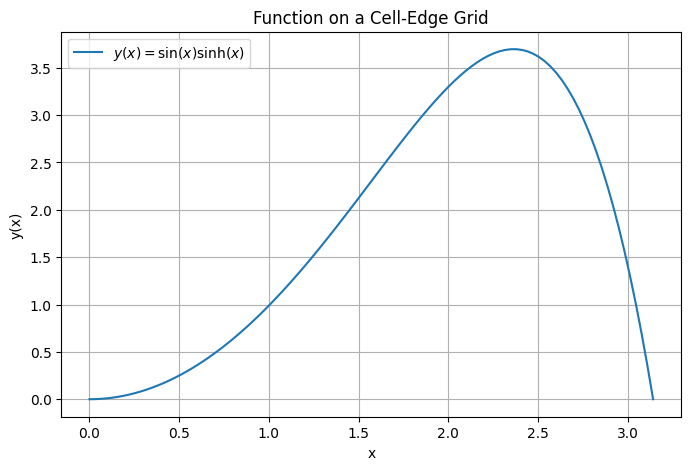

In [5]:
# Function
y = np.sin(x) * np.sinh(x)

# Print grid spacing
print("Grid spacing h=", h)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r'$y(x)=\sin(x)\sinh(x)$')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Function on a Cell-Edge Grid')
plt.grid(True)
plt.legend()
plt.show()

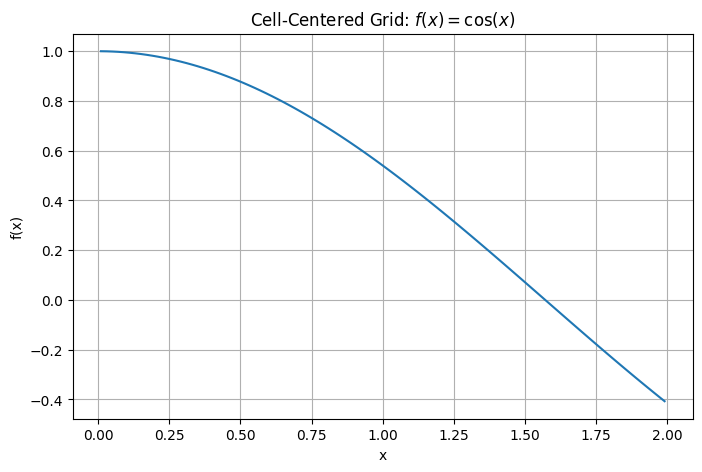

In [10]:
c = 0
d = 2

# Cell width
h = (d - c) / N

# Cell-centered grid
x = np.arange(c + h/2, d, h)

# Function values
f = np.cos(x)

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, f)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'Cell-Centered Grid: $f(x)=\cos(x)$')
plt.grid(True)
plt.show()

In [9]:
# Midpoint integration rule
A_numeric = np.sum(f) * h

# Exact integral
A_exact = np.sin(2)

# Print results
print("Numerical integral =", A_numeric)
print("Exact integral     =", A_exact)
print("Absolute error     =", abs(A_numeric - A_exact))

Numerical integral = -4.5342290474112215e-17
Exact integral     = 0.9092974268256817
Absolute error     = 0.9092974268256817


Consider a differential equation:
$$
    y''(x) + 9 y(x) = \sin(x) \quad ; \quad y(0) = 0, y(2) = 1
$$

In [7]:
import sympy as sp

x = sp.symbols('x')
C1, C2 = sp.symbols('C1 C2')

y = C1*sp.cos(3*x) + C2*sp.sin(3*x) + sp.sin(x)/8

# Apply boundary conditions
eq1 = sp.Eq(y.subs(x, 0), 0)
eq2 = sp.Eq(y.subs(x, 2), 1)

sol = sp.solve([eq1, eq2], (C1, C2))

y_final = y.subs(sol)
sp.simplify(y_final)

(sin(6)*sin(x) + (8 - sin(2))*sin(3*x))/(8*sin(6))

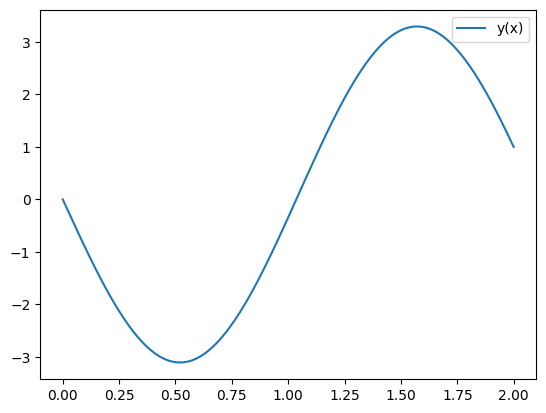

In [6]:
def ode(x, y):
    return np.vstack((y[1], -9*y[0] + np.sin(x)))

def bc(ya, yb):
    return np.array([ya[0], yb[0] - 1])  # y(0)=0, y(2)=1

x = np.linspace(0, 2, 100)
y_guess = np.zeros((2, x.size))

sol = solve_bvp(ode, bc, x, y_guess)

# Plot
x_plot = np.linspace(0, 2, 200)
y_plot = sol.sol(x_plot)[0]

plt.plot(x_plot, y_plot, label="y(x)")
plt.legend()
plt.show()